In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [58]:
df_train = pd.read_csv('train.csv', index_col='id')
df_test = pd.read_csv('test.csv', index_col='id')
sample = pd.read_csv('sample_submission.csv', index_col='id')

In [59]:
print(df_train.info())
print()
print(df_test.info())
target = 'satisfaction'

<class 'pandas.core.frame.DataFrame'>
Index: 699635 entries, 0 to 699634
Data columns (total 22 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Age                                699635 non-null  int64  
 1   Flight Distance                    699635 non-null  int64  
 2   Inflight wifi service              699635 non-null  int64  
 3   Departure/Arrival time convenient  699635 non-null  int64  
 4   Ease of Online booking             699635 non-null  int64  
 5   Gate location                      699635 non-null  int64  
 6   Food and drink                     699635 non-null  int64  
 7   Online boarding                    699635 non-null  int64  
 8   Seat comfort                       699635 non-null  int64  
 9   Inflight entertainment             699635 non-null  int64  
 10  On-board service                   699635 non-null  int64  
 11  Leg room service                   699635 no

In [ ]:
# We will use label encoding to convert 'Male' to 1 and 'Female' to 0 and change the data type to boolean.
df_train['Gender'] = df_train['Gender'].map({'Male': 1, 'Female': 0}).astype(bool)
df_test['Gender'] = df_test['Gender'].map({'Male': 1, 'Female': 0}).astype(bool)

# We will use label encoding to convert 'Loyal Customer' to 1 and 'disloyal Customer' to 0 and change the data type to boolean.
df_train['Customer Type'] = df_train['Customer Type'].map({'Loyal Customer': 1, 'disloyal Customer': 0}).astype(bool)
df_test['Customer Type'] = df_test['Customer Type'].map({'Loyal Customer': 1, 'disloyal Customer': 0}).astype(bool)

#  will use label encoding to convert 'Business travel' to 1 and 'Personal Travel' to 0 and change the data type to boolean.
df_train['Type of Travel'] = df_train['Type of Travel'].map({'Business travel': 1, 'Personal Travel': 0}).astype(bool)
df_test['Type of Travel'] = df_test['Type of Travel'].map({'Business travel': 1, 'Personal Travel': 0}).astype(bool)

# We will use label encoding to convert 'Eco' to 1, 'Eco Plus' to 2 and 'Business' to 3 and change the data type to integer.
df_train['Class'] = df_train['Class'].map({'Eco': 1, 'Eco Plus': 2, 'Business': 3}).astype(int)
df_test['Class'] = df_test['Class'].map({'Eco': 1, 'Eco Plus': 2, 'Business': 3}).astype(int)

Age 75


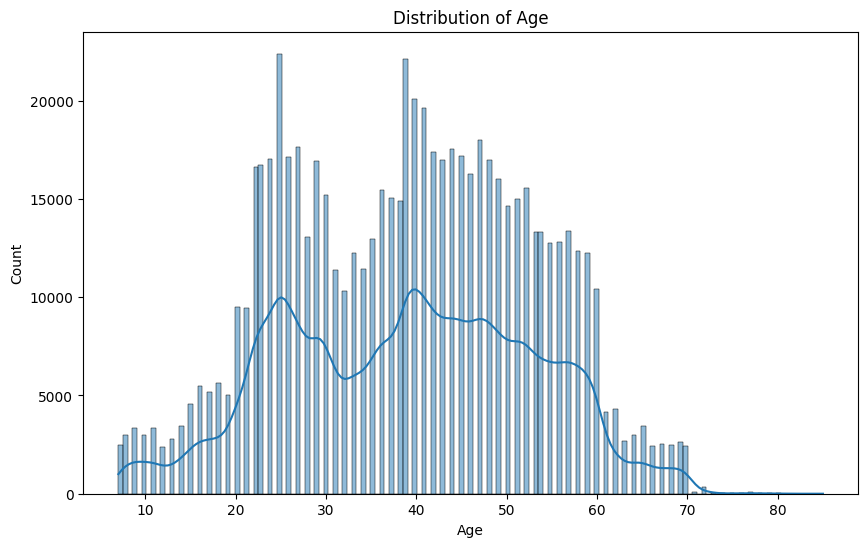

Flight Distance 3474


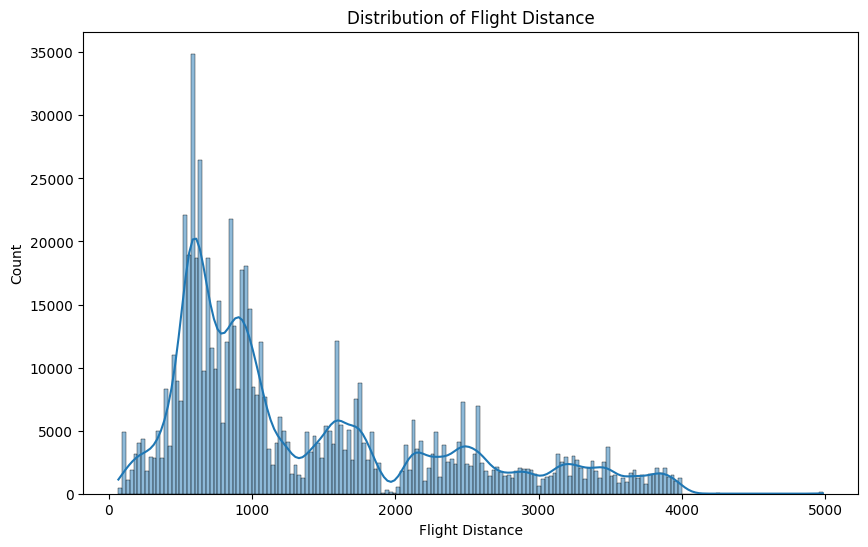

Inflight wifi service 6


TypeError: Axes.text() missing 2 required positional arguments: 'y' and 's'

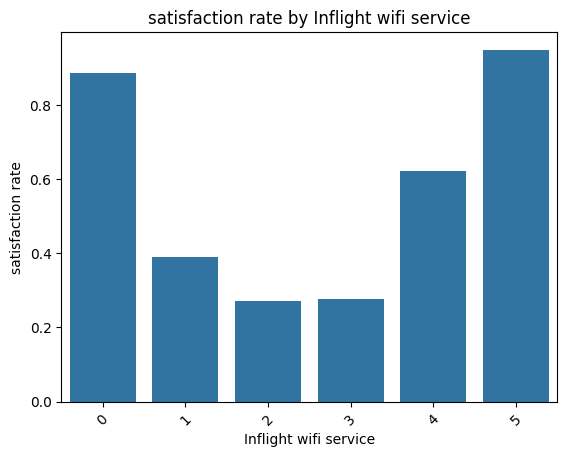

In [81]:
for col in df_train.columns:
    print(col, df_train[col].nunique())
    if df_train[col].nunique() < 10 and col != target:
        target_rate = df_train.groupby(col)[target].mean().sort_values(ascending=False)
        # Count for each category
        counts = df_train[col].value_counts()
        ax = sns.barplot(
            x=target_rate.index,
            y=target_rate.values
        )
        plt.title(f'{target} rate by {col}')
        plt.xlabel(col)
        plt.ylabel(f'{target} rate')
        plt.xticks(rotation=45)

        # Add count above each bar
        for i, category in enumerate(target_rate.index):
            count = counts[category]
            ax.text(
                count,
                ha='center',
                va='center',
                color='red'
            )
        
        plt.show()
            
    if df_train[col].nunique() > 9 and col != target:
        plt.figure(figsize=(10, 6))
        sns.histplot(x=df_train[col], kde=True)
        plt.title(f'Distribution of {col}')
        plt.xlabel(col)
        plt.ylabel('Count')
        plt.show()